# Random FDLU noising arbitrary sites

Created: 26-06-2026

Objectives:
* Build off [previous notebook](random_fdlu_noising_more_sites_4_site_defect_operators.ipynb), but implement several changes to analyse differenct cases:
   1. Just use cluster state fixed state, so don't have to use ED.
   2. Generalize code to handle arbitrary defect and symmetry regions.
   3. Work through increasingly complex FDLU geometries.

# Imports

In [1]:
import numpy as np

In [266]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from scipy.stats import ortho_group

In [8]:
from collections import Counter

In [9]:
import pandas as pd

In [300]:
from time import time

# Definitions
## Construct cluster state

In [10]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [11]:
qu_up_X_state = qtn.Tensor(
    data=np_up_X_state,
    inds=('k',),
    tags='prod'
)

In [12]:
np_CZ = np.diag([1,1,1,-1])

In [13]:
np_CZ

array([[ 1,  0,  0,  0],
       [ 0,  1,  0,  0],
       [ 0,  0,  1,  0],
       [ 0,  0,  0, -1]])

In [14]:
np_CZ = np_CZ.reshape((2,)*4)

In [15]:
np_CZ

array([[[[ 1,  0],
         [ 0,  0]],

        [[ 0,  1],
         [ 0,  0]]],


       [[[ 0,  0],
         [ 1,  0]],

        [[ 0,  0],
         [ 0, -1]]]])

In [16]:
qu_CZ = qtn.Tensor(
    data=np_CZ,
    inds=('k1', 'k2', 'b1', 'b2'),
    tags='CZ'
)

In [17]:
def get_cluster_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'kc_1_{i}'})
        for i in range(num_sites)
    ]

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_1_{i}',
            'b2': f'kc_1_{i+1}',
            'k1': f'kc_2_{i}',
            'k2': f'kc_2_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_2_{i}',
            'b2': f'kc_2_{(i+1)%num_sites}',
            'k1': f'k{i}',
            'k2': f'k{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    out.mangle_inner_()

    return out

In [18]:
psi = get_cluster_state_qu_tensor_network(12)

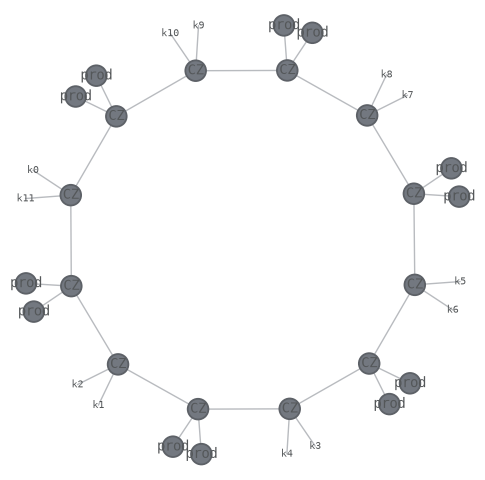

In [19]:
psi.draw()

Looks good. Weird, but good.

## Symmetries
Symmetry of the system is $XK$, where $K$ is complex conjugation.

In [20]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [21]:
np_X = np.array([
    [0,1],
    [1,0]
])

In [22]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

## Defect operators

In [23]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(4, 12)),
    'left_symmetry_sites': list(range(4, 8)),
    'right_symmetry_sites': list(range(8, 12)),
    'left_defect_sites': [4,5],
    'right_defect_sites': [10,11]
}

In [24]:
symmetry_sites = list(range(5, 19))
left_symmetry_sites = list(range(5,12))
right_symmetry_sites = list(range(12,19))

num_symmetry_sites = len(symmetry_sites)

num_defect_op_sites = 4

num_left_symmetry_non_defect_sites = (
    len(left_symmetry_sites)
    - num_defect_op_sites
)

num_right_symmetry_non_defect_sites = (
    len(right_symmetry_sites)
    - num_defect_op_sites
)

defect_op_dim = 2**num_defect_op_sites

In [25]:
horiztonal_bond_dimension = 16
vertical_bond_dimension = 4

In [26]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [27]:
def get_rho_A(A):
    A_bottom = A.conj().reindex({'kl': 'bl', 'kr': 'br'})
    return A & A_bottom

In [28]:
def rho_A_trace(rho_A):
    out = (
        rho_A
        .reindex({'bl': 'kl', 'br': 'kr'})
        .contract()
    )
    return out

In [269]:
def normalize_A(A):
    rho_A = get_rho_A(A)
    trace = rho_A_trace(rho_A)
    A = A.multiply(trace**(-0.5))

    A_0 = A.tensors[0]
    A_1 = A.tensors[1]
    
    norm_0 = jnp.sqrt(jnp.real((A_0 & A_0.conj()).contract()))
    norm_1 = jnp.sqrt(jnp.real((A_1 & A_1.conj()).contract()))

    A.tensors[0].modify(data=A_0.data*jnp.sqrt(norm_1/norm_0))
    A.tensors[1].modify(data=A_1.data*jnp.sqrt(norm_0/norm_1))

    return A

In [30]:
transpose_reindex_dict = {
    'bl': 'kl',
    'br': 'kr',
    'kl': 'bl',
    'kr': 'br'
}

In [31]:
def rho_A_purity(rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho_A
    )

    out = tn.contract()

    return out

In [32]:
def rho_A_rho_overlap(rho, rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho
    )

    out = tn.contract()

    return out

In [33]:
def loss_func(A, rho, rho_purity):
    rho_A = get_rho_A(A)

    out = np.real(
        rho_purity
        + rho_A_purity(rho_A)
        -2*rho_A_rho_overlap(rho, rho_A)
    )

    return out

In [258]:
def get_tensor_network_factorization(qt_rho, rho_purity, domains_dict):
    # Assuming there is an even number of symmetry sites.
    A_left = qtn.Tensor(
        data=random_uniform_complex((
            vertical_bond_dimension,
            2**(len(domains_dict['left_symmetry_sites'])),
            horiztonal_bond_dimension
        )),
        inds=('vLV', 'kl', 'vH')
    )
    
    A_right = qtn.Tensor(
        data=random_uniform_complex((
            horiztonal_bond_dimension,
            2**(len(domains_dict['right_symmetry_sites'])),
            vertical_bond_dimension
        )),
        inds=('vH', 'kr', 'vRV')
    )

    A = qtn.TensorNetwork([A_left, A_right])

    tnopt = qtn.TNOptimizer(
        A,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="L-BFGS-B",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize_basinhopping(n=100,  nhop=5)

    tnopt = qtn.TNOptimizer(
        A_opt,  # the tensor network we want to optimize
        loss_func,  # the function we want to minimize
        norm_fn=normalize_A,
        loss_constants={"rho": qt_rho, "rho_purity": rho_purity},
        autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
        optimizer="adam",  # the optimization algorithm
        progbar=False
    )

    A_opt = tnopt.optimize(n=200)

    return A_opt, tnopt.losses, tnopt.loss_best

In [35]:
def schmidt_decompose_tensor_factorization(A_opt):
    # Left side
    A_l_opt = A_opt.tensors[0]

    tn_l = (
        A_l_opt
        &
        A_l_opt.conj().reindex({'kl': 'bl', 'vH': 'vBH'})
    )
    tn_l = tn_l.contract()

    left_rho_decomp = qtn.tensor_core.tensor_split(
        tn_l,
        left_inds=['kl', 'vH'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vLV'
    )

    diff_l = (
        left_rho_decomp.contract(output_inds=tn_l.inds)
        - tn_l
    )

    left_diff = (diff_l & diff_l.conj()).contract()

    # Right side
    A_r_opt = A_opt.tensors[1]

    tn_r = (
        A_r_opt
        &
        A_r_opt.conj().reindex({'kr': 'br', 'vH': 'vBH'})
    )
    tn_r = tn_r.contract()

    right_rho_decomp = qtn.tensor_core.tensor_split(
        tn_r,
        left_inds=['kr', 'vH'],
        method='svd',
        #cutoff=1e-3,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vRV'
    )

    diff_r = (
        right_rho_decomp.contract(output_inds=tn_r.inds)
        - tn_r
    )

    right_diff = (diff_r & diff_r.conj()).contract()

    out = (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    )

    return out

In [71]:
def get_defect_operators(edm, num_iters=20):
    # Assuming edm has indices [kl1, kr2, bl1, br2] each with size 4 (s sites)
    scores = list()

    left_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('bl1'), edm.ind_size('kl1')),
        inds=['kl1', 'bl1'],
        dtype='complex64'
    )

    right_defect_op = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('br2'), edm.ind_size('kr2')),
        inds=['kr2', 'br2'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (
            (
                edm
                & left_defect_op.reindex({'kl1': 'bl1', 'bl1':'kl1'})
            )
            .contract()
        )
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        right_defect_op = qtn.Tensor(sol, inds = ['kr2', 'br2'])
        
        left_edm = (
            (
                edm
                & right_defect_op.reindex({'kr2': 'br2', 'br2':'kr2'})
            )
            .contract()    
        )
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        left_defect_op = qtn.Tensor(sol, inds = ['kl1', 'bl1'])

    return (left_defect_op, right_defect_op), scores

In [73]:
def get_defect_ops_and_indices_from_density_matrix(qt_rho, domains_dict):
    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        cutoff=1e-2,
        cutoff_mode='abs',
        absorb=None,
        renorm=False,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    bra_conjugate_rho = (
        rho_purification.tensors[0]
        & rho_purification.tensors[1]
        & (rho_purification.tensors[2].conj())
    )

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )

    (
        bra_conjugate_rho
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
            shape_map={
                'kl': (left_defect_op_dim, left_defect_complement_op_dim),
                'kr': (right_defect_complement_op_dim, right_defect_op_dim)
            }
        )
    )

    (
        bra_conjugate_rho
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2'], 'br': ['br1', 'br2']},
            shape_map={
                'bl': (left_defect_op_dim, left_defect_complement_op_dim),
                'br': (right_defect_complement_op_dim, right_defect_op_dim)
            }
        )
    )

    left_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['left_defect_sites'])
    )
    right_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['right_defect_sites'])
    )
    left_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    
    )
    right_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )

    # Effective density matrix
    edm = (
        bra_conjugate_rho.reindex(
            {'bl1': 'bbl1', 'bl2': 'bl2', 'br1': 'br1', 'br2': 'bbr2'}
        )
        & left_defect_qu_X.reindex({'k': 'bl1', 'b': 'bbl1'})
        & left_defect_complement_qu_X.reindex({'k': 'kl2', 'b': 'bl2'})
        & right_defect_complement_qu_X.reindex({'k': 'kr1', 'b': 'br1'})
        & right_defect_qu_X.reindex({'k': 'br2', 'b': 'bbr2'})
    )

    # Ordering of indices important here.
    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={
                'kl': (left_defect_op_dim, left_defect_complement_op_dim),
                'bl': (left_defect_op_dim, left_defect_complement_op_dim)
            }
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & left_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & left_defect_qu_X.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={
                'kr': (right_defect_complement_op_dim, right_defect_op_dim),
                'br': (right_defect_complement_op_dim, right_defect_op_dim)
            }
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & right_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & right_defect_qu_X.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps,
        purification_diff_score
    )

    return out

In [38]:
def get_defect_ops_and_indices_from_factorized_density_matrix(qt_rho,
    left_rho_decomp, right_rho_decomp, domains_dict):

    bra_conjugate_left_rho_decomp = (
        left_rho_decomp.tensors[0]
        & left_rho_decomp.tensors[1]
        & (left_rho_decomp.tensors[2].conj())
    )
    
    bra_conjugate_right_rho_decomp = (
        right_rho_decomp.tensors[0]
        & right_rho_decomp.tensors[1]
        & (right_rho_decomp.tensors[2].conj())
    )

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )

    (
        bra_conjugate_left_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2']},
            shape_map={
                'kl': (left_defect_op_dim, left_defect_complement_op_dim)
            }
        )
    )
    
    (
        bra_conjugate_left_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'bl': ['bl1', 'bl2']},
            shape_map={
                'bl': (left_defect_op_dim, left_defect_complement_op_dim)
            }
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[0]
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2']},
            shape_map={'kr': (right_defect_complement_op_dim, right_defect_op_dim)}
        )
    )
    
    (
        bra_conjugate_right_rho_decomp
        .tensors[2]
        .unfuse_(
            unfuse_map={'br': ['br1', 'br2']},
            shape_map={'br': (right_defect_complement_op_dim, right_defect_op_dim)}
        )
    )

    left_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['left_defect_sites'])
    )
    right_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['right_defect_sites'])
    )
    left_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    
    )
    right_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    # Effective density matrix
    edm = (
        bra_conjugate_left_rho_decomp.reindex({'bl1': 'bbl1', 'bl2': 'bl2'})
        & left_defect_qu_X.reindex({'k': 'bl1', 'b': 'bbl1'})
        & left_defect_complement_qu_X.reindex({'k': 'kl2', 'b': 'bl2'})
        & right_defect_complement_qu_X.reindex({'k': 'kr1', 'b': 'br1'})
        & right_defect_qu_X.reindex({'k': 'br2', 'b': 'bbr2'})
        & bra_conjugate_right_rho_decomp.reindex({'br1': 'br1', 'br2': 'bbr2'})
    )

    edm = edm.contract(output_inds=['kl1', 'kr2', 'bl1', 'br2'])

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_defect_l = (
        qt_rho
        .reindex({'kr': 'br'})
        .contract()
        .unfuse_(
            unfuse_map={'kl': ['kl1', 'kl2'], 'bl': ['bl1', 'bl2']},
            shape_map={
                'kl': (left_defect_op_dim, left_defect_complement_op_dim),
                'bl': (left_defect_op_dim, left_defect_complement_op_dim)
            }
        )
        .reindex({'kl2': 'bl2'})
        .contract()
    )

    left_defect_op_invariant = (
        rho_defect_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & left_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & left_defect_qu_X.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_defect_r = (
        qt_rho
        .reindex({'kl': 'bl'})
        .contract()
        .unfuse_(
            unfuse_map={'kr': ['kr1', 'kr2'], 'br': ['br1', 'br2']},
            shape_map={
                'kr': (right_defect_complement_op_dim, right_defect_op_dim),
                'br': (right_defect_complement_op_dim, right_defect_op_dim)
            }
        )
        .reindex({'kr1': 'br1'})
        .contract()
    )

    right_defect_op_invariant = (
        rho_defect_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & right_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & right_defect_qu_X.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())

    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [39]:
def get_defect_ops_and_indices_from_restricted_state(psi_restricted, domains_dict):
    psi_0 = psi_restricted

    left_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['left_defect_sites'])
    )
    right_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['right_defect_sites'])
    )
    left_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    
    )
    right_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )

    # Effective density matrix
    edm = (
        psi_0
        & left_defect_qu_X.reindex({'k': 'bl1', 'b': 'bbl1'})
        & left_defect_complement_qu_X.reindex({'k': 'kl2', 'b': 'bl2'})
        & right_defect_complement_qu_X.reindex({'k': 'kr1', 'b': 'br1'})
        & right_defect_qu_X.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )
    
    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & left_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & left_defect_qu_X.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & right_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & right_defect_qu_X.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    overlap = (
        edm
        & left_defect_operator.reindex({'kl1': 'bl1', 'bl1': 'kl1'})
        & right_defect_operator.reindex({'kr2': 'br2', 'br2': 'kr2'})
    )

    overlap = np.abs(overlap.contract())
    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlap
    )

    return out

In [40]:
def get_defect_ops_and_indices_from_restricted_purification_state(
    psi_restricted, domains_dict):
    psi_0 = psi_restricted

    left_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['left_defect_sites'])
    )
    right_defect_qu_X = get_multisite_qu_X(
        len(domains_dict['right_defect_sites'])
    )
    left_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    
    )
    right_defect_complement_qu_X = get_multisite_qu_X(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )

    # Effective density matrix
    edm = (
        psi_0
        & left_defect_qu_X.reindex({'k': 'bl1', 'b': 'bbl1'})
        & left_defect_complement_qu_X.reindex({'k': 'kl2', 'b': 'bl2'})
        & left_defect_complement_qu_X.reindex({'k': 'kr1', 'b': 'br1'})
        & right_defect_qu_X.reindex({'k': 'br2', 'b': 'bbr2'})
        & psi_0.reindex({
            'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
        })
    )

    edm = edm.contract()

    split_edm = qtn.tensor_core.tensor_split(
        edm,
        left_inds=['kl1', 'bl1'],
        absorb=None,
        bond_ind='vH'
    )

    left_right_singular_vals = split_edm.tensors[1].data

    (left_defect_operator, right_defect_operator), overlaps = (
        get_defect_operators(edm, num_iters=20)
    )

    rho_0 = (
        psi_0
        & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
    )

    rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

    left_defect_op_invariant = (
        rho_0_l
        & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
        & left_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
        & left_defect_qu_X.reindex({'b': 'ki3', 'k': 'bl1'}) 
    )
    left_defect_op_invariant=left_defect_op_invariant.contract()

    rho_0_r = rho_0.reindex({'bl1': 'kl1'}).contract()

    right_defect_op_invariant = (
        rho_0_r
        & right_defect_operator.reindex({'br2': 'kr2', 'kr2': 'ki1'})
        & right_defect_qu_X.reindex({'b': 'ki1', 'k': 'ki2'}) 
        & right_defect_operator.conj().reindex({'br2': 'ki2', 'kr2': 'ki3'})
        & right_defect_qu_X.reindex({'b': 'ki3', 'k': 'br2'}) 
    )
    right_defect_op_invariant=right_defect_op_invariant.contract()

    
    out = (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        overlaps
    )

    return out

In [41]:
def get_restricted_psis(left_rho_decomp, right_rho_decomp, domains_dict, 
                        cutoff_factor=0.8):
    out = list()

    left_schmidt_vals = left_rho_decomp.tensors[1].data
    right_schmidt_vals = right_rho_decomp.tensors[1].data

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    for i, sl in enumerate(left_schmidt_vals):
        if sl >= cutoff_factor*max(left_schmidt_vals):
            left_psi = left_rho_decomp.tensors[0].isel({'vLV': i})
            for j, sr in enumerate(right_schmidt_vals):
                if sr >= cutoff_factor*max(right_schmidt_vals):
                    right_psi = right_rho_decomp.tensors[0].isel({'vRV': j})

                    psi = left_psi & right_psi
                    psi_norm = (psi & psi.conj()).contract()

                    (
                        psi
                        .multiply(
                            psi_norm**(-0.5),
                            inplace=True,
                            spread_over=2
                        )
                    )

                    (
                        psi
                        .tensors[0]
                        .unfuse_(
                            unfuse_map={'kl': ['kl1', 'kl2']},
                            shape_map={
                                'kl': (left_defect_op_dim, left_defect_complement_op_dim)
                            }
                        )
                    )

                    (
                        psi
                        .tensors[1]
                        .unfuse_(
                            unfuse_map={'kr': ['kr1', 'kr2']},
                            shape_map={
                                'kr': (right_defect_complement_op_dim, right_defect_op_dim)
                            }
                        )
                    )

                    out.append([psi, sl, sr])

    return out

In [42]:
def get_restricted_psis_from_purification(qt_rho, domains_dict,
                                          cutoff_factor=0.65):
    out = list()

    rho_purification = qtn.tensor_core.tensor_split(
        qt_rho,
        left_inds=['kl', 'kr'],
        method='eigh',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    purification_diff = rho_purification.contract(output_inds=qt_rho.inds) - qt_rho
    purification_diff_score = (purification_diff & purification_diff.conj()).contract()

    schmidt_vals = rho_purification.tensors[1].data

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )

    for i, schmidt_val in enumerate(schmidt_vals):
        if schmidt_val >= cutoff_factor*max(schmidt_vals):
            psi = rho_purification.tensors[0].isel({'vV': i})
            psi_norm = (psi & psi.conj()).contract()

            psi = psi_norm**(-0.5)*psi

            (
                psi
                .unfuse_(
                    unfuse_map={'kl': ['kl1', 'kl2'], 'kr': ['kr1', 'kr2']},
                    shape_map={
                        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
                        'kr': (right_defect_complement_op_dim, right_defect_op_dim)
                    }
                )
            )

            out.append([psi, schmidt_val])

    return (out, purification_diff_score)

In [199]:
def get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict):
    unfuse_map = {
        'kl': ['kl1', 'kl2'],
        'kr': ['kr1', 'kr2'],
        'bl': ['bl1', 'bl2'],
        'br': ['br1', 'br2']
    }

    left_defect_op_dim = 2**(len(domains_dict['left_defect_sites']))
    right_defect_op_dim = 2**(len(domains_dict['right_defect_sites']))
    left_defect_complement_op_dim = 2**(
        len(domains_dict['left_symmetry_sites'])
        -len(domains_dict['left_defect_sites'])
    )
    right_defect_complement_op_dim = 2**(
        len(domains_dict['right_symmetry_sites'])
        -len(domains_dict['right_defect_sites'])
    )
    
    shape_map = {
        'kl': (left_defect_op_dim, left_defect_complement_op_dim),
        'kr': (left_defect_complement_op_dim, left_defect_op_dim),
        'bl': (right_defect_op_dim, right_defect_complement_op_dim),
        'br': (right_defect_complement_op_dim, right_defect_op_dim)
    }

    rho = (
        qt_rho
        .unfuse(unfuse_map=unfuse_map, shape_map=shape_map)
    )

    rho = rho.reindex({'kl2': 'bl2', 'kr1': 'br1'})
    rho = rho.contract()

    rho_left_right_split = qtn.tensor_core.tensor_split(
        rho,
        left_inds=['kl1', 'bl1'],
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=True,
        bond_ind='vV'
    )

    rho_left_right_schmidt_vals = rho_left_right_split.tensors[1].data

    return rho_left_right_schmidt_vals

In [200]:
def get_rdm_from_quimb_psi(psi, symmetry_sites):
    rho = qtn.TensorNetwork(
        [psi, psi.conj().reindex({f'k{i}': f'b{i}' for i in symmetry_sites})],
        virtual=True
    )

    rho.contract(inplace=True)

    return rho

In [45]:
def get_purity_from_quimb_rdm(rdm):
    rdm_indices = rdm.outer_inds()

    k_indices = [s for s in rdm_indices if s.startswith('k')]
    b_indices = [s for s in rdm_indices if s.startswith('b')]

    rdm_transpose_map = {
        **{s: f'b{s[1:]}' for s in k_indices},
        **{s: f'k{s[1:]}' for s in b_indices}
    }

    out = (
        rdm
        & rdm.reindex(rdm_transpose_map)
    )
    out.contract(inplace=True)
    out = np.real(out.item())

    return out

In [58]:
def extract_time_reversal_information(psi, domains_dict):
    # Assume psi is a quimb tensor/tensor network with indices for each site.
    rho = get_rdm_from_quimb_psi(psi, domains_dict['symmetry_sites'])
    
    rho_purity = get_purity_from_quimb_rdm(rho)
    
    # Hardcode warning
    qt_rho = (
        rho
        .tensors[0]
        .fuse({
            'kl': [f'k{i}' for i in domains_dict['left_symmetry_sites']],
            'kr': [f'k{i}' for i in domains_dict['right_symmetry_sites']],
            'bl': [f'b{i}' for i in domains_dict['left_symmetry_sites']],
            'br': [f'b{i}' for i in domains_dict['right_symmetry_sites']]
        })
    )

    qt_rho_left_right_schmidt_vals = (
        get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict)
    )

    rho_out = get_defect_ops_and_indices_from_density_matrix(qt_rho, domains_dict)

    pair = get_restricted_psis_from_purification(qt_rho, domains_dict)
    purification_restricted_psi_pairs, purification_diff_score = pair

    purification_restricted_psi_output = list()
    for psi_0, sv in purification_restricted_psi_pairs:
        purification_restricted_psi_output.append(
            [
                sv,
                *get_defect_ops_and_indices_from_restricted_purification_state(
                    psi_0,
                    domains_dict
                )
            ]
        )
    
    A_opt, A_losses, A_opt_best_loss = get_tensor_network_factorization(
        qt_rho,
        rho_purity,
        domains_dict
    )

    schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)
    
    (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    ) = schmidt_decomp_out

    rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
        qt_rho,
        left_rho_decomp,
        right_rho_decomp,
        domains_dict
    )

    (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps
    ) = rho_defect_out

    restricted_psi_triples = get_restricted_psis(
        left_rho_decomp,
        right_rho_decomp,
        domains_dict
    )

    restricted_psi_output = list()
    for psi_0, sl, sr in restricted_psi_triples:
        restricted_psi_output.append(
            [
                sl, sr,
                *get_defect_ops_and_indices_from_restricted_state(
                    psi_0, domains_dict
                )
            ]
        )

    out = (
        qt_rho_left_right_schmidt_vals,
        rho_out,
        purification_diff_score,
        purification_restricted_psi_output,
        A_losses,
        A_opt_best_loss,
        left_diff,
        right_diff,
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps,
        restricted_psi_output
    )

    return out

In [59]:
def extract_factorization_time_reversal_information(psi, domains_dict):
    # Assume psi is a quimb tensor/tensor network with indices for each site.
    rho = get_rdm_from_quimb_psi(psi, domains_dict['symmetry_sites'])
    
    rho_purity = get_purity_from_quimb_rdm(rho)
    
    # Hardcode warning
    qt_rho = (
        rho
        .tensors[0]
        .fuse({
            'kl': [f'k{i}' for i in domains_dict['left_symmetry_sites']],
            'kr': [f'k{i}' for i in domains_dict['right_symmetry_sites']],
            'bl': [f'b{i}' for i in domains_dict['left_symmetry_sites']],
            'br': [f'b{i}' for i in domains_dict['right_symmetry_sites']]
        })
    )

    qt_rho_left_right_schmidt_vals = (
        get_left_right_defect_regions_schmidt_vals(qt_rho, domains_dict)
    )
    
    A_opt, A_losses, A_opt_best_loss = get_tensor_network_factorization(
        qt_rho,
        rho_purity,
        domains_dict
    )

    schmidt_decomp_out = schmidt_decompose_tensor_factorization(A_opt)
    
    (
        left_rho_decomp,
        right_rho_decomp,
        left_diff,
        right_diff
    ) = schmidt_decomp_out

    rho_defect_out = get_defect_ops_and_indices_from_factorized_density_matrix(
        qt_rho,
        left_rho_decomp,
        right_rho_decomp,
        domains_dict
    )

    (
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps
    ) = rho_defect_out

    restricted_psi_triples = get_restricted_psis(
        left_rho_decomp,
        right_rho_decomp,
        domains_dict
    )

    restricted_psi_output = list()
    for psi_0, sl, sr in restricted_psi_triples:
        restricted_psi_output.append(
            [
                sl, sr,
                *get_defect_ops_and_indices_from_restricted_state(
                    psi_0, domains_dict
                )
            ]
        )

    out = (
        qt_rho_left_right_schmidt_vals,
        A_losses,
        A_opt_best_loss,
        left_diff,
        right_diff,
        left_right_singular_vals,
        left_defect_op_invariant,
        right_defect_op_invariant,
        rho_defect_ops_overlaps,
        restricted_psi_output
    )

    return out

## Apply random unitary to groundstate

In [97]:
# Hard code warning
def generate_random_symmetry_respecting_unitary():
    o = ortho_group.rvs(4)

    np_H = np.pow(2, -1/2)*np.array([
        [1,1],
        [1,-1]
    ])

    np_W = np.kron(np_H, np_H) @ np.diag([1, 1j, 1j, 1])

    u = np_W @ o @ (np_W.conj().T)

    return u

In [129]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quimb_state(psi, domains_dict, depth, offset=0):
    num_sites = domains_dict['num_system_sites']

    all_circuit_lists = [
        list() for _ in range(depth)
    ]

    for layer, circuit_list in enumerate(all_circuit_lists):
        delta = layer
    
        for i in range(num_sites//2):
            site_1 = ((2*i)+delta+offset)%num_sites
            site_2 = ((2*i)+1+delta+offset)%num_sites

            u = generate_random_symmetry_respecting_unitary()

            inds=[
                f'k_{layer+1}_{site_1}',
                f'k_{layer+1}_{site_2}',
                f'k_{layer}_{site_1}',
                f'k_{layer}_{site_2}'
            ]
            
            qu_u = qtn.Tensor(
                u.reshape((2,)*4),
                inds=inds,
                tags=f'Layer_{layer}'
            )

            circuit_list.append(qu_u)

    all_tensors = (
        [psi.reindex({f'k{i}': f'k_0_{i}' for i in range(num_sites)})]
        + sum(all_circuit_lists, start=[])
    )

    out = (
        qtn
        .TensorNetwork(all_tensors, virtual=False)
        .mangle_inner_()
        .reindex({f'k_{depth}_{i}': f'k{i}' for i in range(num_sites)}) 
    )

    return out

In [50]:
def extract_time_reversal_information_after_random_fdlu(psi, domains_dict,
    num_random_states=20):

    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
        out.append(extract_time_reversal_information(rand_psi, domains_dict))

    return out

In [51]:
def extract_factorization_time_reversal_information_after_random_fdlu(psi,
    domains_dict, num_random_states=20):
    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
        data = extract_factorization_time_reversal_information(
            rand_psi,
            domains_dict
        )
        out.append(data)

    return out

In [52]:
def get_quimb_psi_from_quspin_psi(quspin_psi):
    quimb_psi = qtn.Tensor(
        quspin_psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    return quimb_psi

# Analysis

## Round 1 - no random circuit

In [105]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(4, 12)),
    'left_symmetry_sites': list(range(4, 8)),
    'right_symmetry_sites': list(range(8, 12)),
    'left_defect_sites': [4,5],
    'right_defect_sites': [10,11]
}

In [106]:
depth=0

In [107]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [108]:
rand_psi = psi

In [109]:
test_out = extract_time_reversal_information(
    rand_psi,
    domains_dict
)

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(


In [110]:
test_out[0]

array([0.25])

In [111]:
test_out[1]

(array([0.25]),
 np.complex128(-0.9999999999999969+0j),
 np.complex128(-0.9999999999999967+0j),
 [np.float64(0.6884755238284109),
  np.float64(0.999999999999996),
  np.float64(0.9999999999999963),
  np.float64(0.999999999999996),
  np.float64(0.999999999999996),
  np.float64(0.999999999999996),
  np.float64(0.999999999999996),
  np.float64(0.999999999999996),
  np.float64(0.9999999999999962),
  np.float64(0.999999999999996),
  np.float64(0.999999999999996),
  np.float64(0.9999999999999961),
  np.float64(0.9999999999999962),
  np.float64(0.999999999999996),
  np.float64(0.9999999999999959),
  np.float64(0.999999999999996),
  np.float64(0.9999999999999961),
  np.float64(0.9999999999999961),
  np.float64(0.9999999999999961),
  np.float64(0.9999999999999961),
  np.float64(0.999999999999996),
  np.float64(0.9999999999999959),
  np.float64(0.999999999999996),
  np.float64(0.999999999999996),
  np.float64(0.999999999999996),
  np.float64(0.999999999999996),
  np.float64(0.9999999999999962),
 

In [112]:
test_out[2]

np.float64(2.6255857986784324e-31)

In [113]:
test_out[3]

[[np.float64(0.2499999999999991),
  array([0.5]),
  np.complex128(-0.9999999999999996+0j),
  np.complex128(-0.9999999999999996+0j),
  [np.float64(0.27390436042505484),
   np.float64(1.0),
   np.float64(0.9999999999999996),
   np.float64(0.9999999999999998),
   np.float64(1.0),
   np.float64(0.9999999999999998),
   np.float64(1.0),
   np.float64(0.9999999999999998),
   np.float64(1.0),
   np.float64(0.9999999999999996),
   np.float64(0.9999999999999999),
   np.float64(1.0),
   np.float64(0.9999999999999998),
   np.float64(0.9999999999999996),
   np.float64(0.9999999999999998),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(1.0),
   np.float64(0.9999999999999996),
   np.float64(0.9999999999999998),
   np.float64(0.9999999999999996),
   np.float64(0.9999999999999998),
   np.float64(1.0),
   np.float64(0.9999999999999998),
   np.float64(1.0),
   np.float64(0.9999999999999996),
   np.float64(0.9999999999999996),
   np.float64(0.9999999999999998),
   np.float64(0.9999999999999996),
  

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


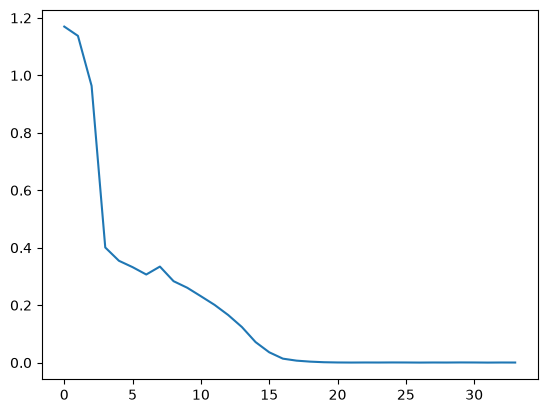

In [114]:
plt.plot(test_out[4])

In [115]:
test_out[6], test_out[7]

(np.complex64(1.2176605e-12+0j), np.complex64(1.3139457e-12+0j))

In [116]:
test_out[8]

array([2.44563190e-01, 8.69146413e-04, 6.30544121e-04, 5.14244647e-04,
       3.18880683e-04, 2.68616075e-04, 2.12534141e-04, 2.02867390e-04,
       1.78739659e-04, 1.64269104e-04, 1.29535649e-04, 1.00833061e-04,
       7.38943016e-05, 4.31902781e-05, 3.83673926e-05, 2.19909958e-05])

In [117]:
test_out[9]

np.complex128(-0.999999999999992-5.551115123125783e-17j)

In [118]:
test_out[10]

np.complex128(-0.9999999999999917+5.551115123125783e-17j)

In [119]:
test_out[11]

[np.float64(0.2722441032100279),
 np.float64(0.9782217855953526),
 np.float64(0.9782465873448492),
 np.float64(0.9782465874020096),
 np.float64(0.9782465874020096),
 np.float64(0.9782465874020101),
 np.float64(0.9782465874020104),
 np.float64(0.9782465874020101),
 np.float64(0.9782465874020099),
 np.float64(0.9782465874020103),
 np.float64(0.9782465874020101),
 np.float64(0.9782465874020096),
 np.float64(0.9782465874020095),
 np.float64(0.9782465874020098),
 np.float64(0.97824658740201),
 np.float64(0.9782465874020101),
 np.float64(0.9782465874020098),
 np.float64(0.9782465874020101),
 np.float64(0.9782465874020095),
 np.float64(0.9782465874020099),
 np.float64(0.9782465874020096),
 np.float64(0.9782465874020101),
 np.float64(0.97824658740201),
 np.float64(0.9782465874020101),
 np.float64(0.9782465874020101),
 np.float64(0.9782465874020101),
 np.float64(0.9782465874020094),
 np.float64(0.97824658740201),
 np.float64(0.9782465874020096),
 np.float64(0.9782465874020096),
 np.float64(0.97

In [120]:
test_out[12]

[[np.float32(0.7157474),
  np.float32(0.7446105),
  array([4.99951662e-01, 1.87472757e-03, 1.41547547e-03, 9.57050522e-04,
         7.20985173e-04, 4.29094177e-04, 3.06966943e-04, 2.22575103e-04,
         2.12360407e-04, 1.75167911e-04, 1.61080643e-05, 1.39481641e-05,
         6.92127039e-06, 2.10956840e-06, 1.30843115e-06, 6.60121549e-07]),
  np.complex128(-0.9999251411655612-2.989412397347291e-07j),
  np.complex128(-0.9999109113534381-1.4309963093650513e-05j),
  np.float64(0.9999127820113494)],
 [np.float32(0.7157474),
  np.float32(0.74044055),
  array([4.99974661e-01, 1.27008809e-03, 1.00750882e-03, 6.67039845e-04,
         5.38743410e-04, 4.78550478e-04, 4.52184450e-04, 3.02732406e-04,
         2.77594799e-04, 2.26141923e-04, 5.37592311e-05, 2.18180378e-05,
         3.17876219e-06, 1.62348254e-06, 9.48509848e-07, 5.61109217e-07]),
  np.complex128(-0.9999568115018994+3.2866209192516926e-06j),
  np.complex128(-0.9999603769554793-7.37596094363413e-06j),
  np.float64(0.9999558128153656

## Round 2 - Depth 1, offset 0

In [122]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(4, 12)),
    'left_symmetry_sites': list(range(4, 8)),
    'right_symmetry_sites': list(range(8, 12)),
    'left_defect_sites': [4,5],
    'right_defect_sites': [10,11]
}

In [123]:
depth=1
offset=0

In [124]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [130]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict, depth, offset)

In [132]:
test_out = extract_time_reversal_information(
    rand_psi,
    domains_dict
)

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(


In [133]:
test_out[0]

array([0.25])

In [134]:
test_out[1]

(array([0.14976644, 0.13582921, 0.10407709, 0.10386721]),
 np.complex128(-0.9999999999966501-2.7755575615628914e-17j),
 np.complex128(-0.9999999999932203-5.551115123125783e-17j),
 [np.float64(0.44181334467955113),
  np.float64(0.4680319914007682),
  np.float64(0.48160600334666437),
  np.float64(0.49812978567479615),
  np.float64(0.5147539045835897),
  np.float64(0.5275210824435614),
  np.float64(0.5352864522285011),
  np.float64(0.5393876696663803),
  np.float64(0.5414175823672729),
  np.float64(0.5423995620023039),
  np.float64(0.5428724870261873),
  np.float64(0.5431007723740269),
  np.float64(0.5432114185507926),
  np.float64(0.5432652616474771),
  np.float64(0.5432915503545939),
  np.float64(0.543304418938503),
  np.float64(0.5433107304398754),
  np.float64(0.5433138303686067),
  np.float64(0.5433153544894991),
  np.float64(0.5433161044048205),
  np.float64(0.5433164735872208),
  np.float64(0.5433166554073932),
  np.float64(0.5433167449789922),
  np.float64(0.5433167891150884),
  n

In [135]:
test_out[2]

np.complex128(4.609223186228589e-31+0j)

In [136]:
test_out[3]

[[np.float64(0.250000000000001),
  array([0.48326346, 0.08993418, 0.08993418, 0.01673654]),
  np.complex128(-0.9999999999999998+0j),
  np.complex128(-1+0j),
  [np.float64(0.7548181536601237),
   np.float64(0.9787515624067893),
   np.float64(0.997155991360315),
   np.float64(0.9996303109862026),
   np.float64(0.9999521306659845),
   np.float64(0.999993804740837),
   np.float64(0.9999991982605538),
   np.float64(0.9999998962463557),
   np.float64(0.9999999865731857),
   np.float64(0.9999999982624287),
   np.float64(0.9999999997751403),
   np.float64(0.9999999999709008),
   np.float64(0.9999999999962342),
   np.float64(0.9999999999995126),
   np.float64(0.9999999999999368),
   np.float64(0.9999999999999916),
   np.float64(0.999999999999999),
   np.float64(0.9999999999999996),
   np.float64(0.9999999999999996),
   np.float64(1.0),
   np.float64(0.9999999999999999),
   np.float64(0.9999999999999998),
   np.float64(1.0000000000000002),
   np.float64(1.0000000000000002),
   np.float64(1.00000

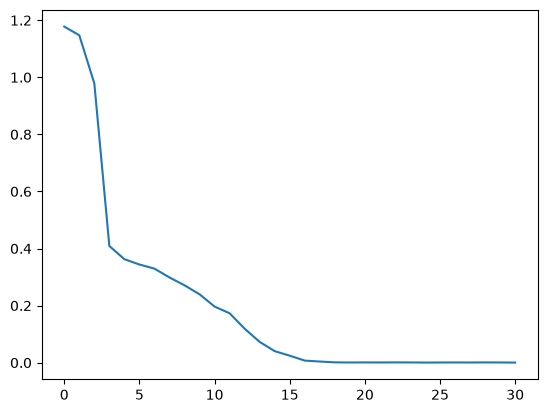

In [137]:
plt.plot(test_out[4])

In [138]:
min(test_out[4])

0.0002696514129638672

In [139]:
test_out[6], test_out[7]

(np.complex64(1.1509366e-12+0j), np.complex64(9.481444e-13+0j))

In [140]:
test_out[8]

array([2.43769319e-01, 4.26675229e-04, 4.01677331e-04, 3.37147150e-04,
       2.58855712e-04, 2.13417815e-04, 2.12297010e-04, 1.54096414e-04,
       1.32927259e-04, 1.28693385e-04, 9.88978311e-05, 8.57598739e-05,
       8.32245298e-05, 3.93593833e-05, 2.84876406e-05, 1.07979421e-05])

In [141]:
test_out[9]

np.complex128(-1.0000000000000009+0j)

In [142]:
test_out[10]

np.complex128(-1.0000000000000013+0j)

In [143]:
test_out[11]

[np.float64(0.7378754911003427),
 np.float64(0.9750511947011465),
 np.float64(0.9750526666474423),
 np.float64(0.9750526666479536),
 np.float64(0.9750526666479532),
 np.float64(0.9750526666479533),
 np.float64(0.9750526666479533),
 np.float64(0.9750526666479534),
 np.float64(0.9750526666479542),
 np.float64(0.9750526666479538),
 np.float64(0.9750526666479538),
 np.float64(0.9750526666479535),
 np.float64(0.9750526666479538),
 np.float64(0.9750526666479535),
 np.float64(0.975052666647954),
 np.float64(0.9750526666479538),
 np.float64(0.9750526666479533),
 np.float64(0.9750526666479533),
 np.float64(0.975052666647954),
 np.float64(0.9750526666479533),
 np.float64(0.9750526666479534),
 np.float64(0.975052666647954),
 np.float64(0.975052666647954),
 np.float64(0.9750526666479538),
 np.float64(0.9750526666479539),
 np.float64(0.9750526666479535),
 np.float64(0.9750526666479534),
 np.float64(0.9750526666479533),
 np.float64(0.9750526666479535),
 np.float64(0.9750526666479533),
 np.float64(0.

In [144]:
test_out[12]

[[np.float32(0.7640523),
  np.float32(0.69116336),
  array([4.99980790e-01, 9.17475152e-04, 6.33026250e-04, 5.23263942e-04,
         4.73227826e-04, 3.89519635e-04, 3.80314167e-04, 2.47610144e-04,
         1.52502389e-04, 9.77507680e-05, 7.14868594e-05, 4.09349060e-05,
         1.00184387e-06, 4.17481513e-07, 1.62391301e-07, 1.39316784e-07]),
  np.complex128(-0.999988647733656+4.075761684818602e-07j),
  np.complex128(-0.9999927508030622-4.001378007323364e-06j),
  np.float64(0.9999641606158409)],
 [np.float32(0.7640523),
  np.float32(0.68859285),
  array([4.99983891e-01, 1.14390708e-03, 6.57320248e-04, 4.92473740e-04,
         4.29997390e-04, 3.70088466e-04, 2.58808091e-04, 1.75743289e-04,
         1.74043408e-04, 1.18462025e-04, 8.28983974e-05, 3.93508383e-05,
         1.39176161e-06, 8.99737305e-07, 3.89262741e-07, 2.38893334e-07]),
  np.complex128(-0.9999926631265629+7.709377430054065e-07j),
  np.complex128(-0.9999839497802334-1.7654960244861684e-06j),
  np.float64(0.9999715663156589

## Round 3 - Depth 1, offset 1

In [145]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(4, 12)),
    'left_symmetry_sites': list(range(4, 8)),
    'right_symmetry_sites': list(range(8, 12)),
    'left_defect_sites': [4,5],
    'right_defect_sites': [10,11]
}

In [146]:
depth=1
offset=1

In [147]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [149]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict, depth, offset)

In [150]:
test_out = extract_time_reversal_information(
    rand_psi,
    domains_dict
)

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(


In [151]:
test_out[0]

array([0.25])

In [152]:
test_out[1]

(array([0.05086548, 0.03692773, 0.03593715, 0.01624269]),
 np.complex128(0.9999999999994351+0j),
 np.complex128(0.9999999999988459-5.551115123125783e-17j),
 [np.float64(0.2540245399535679),
  np.float64(0.1573268847456336),
  np.float64(0.1669898795847991),
  np.float64(0.172459360793962),
  np.float64(0.17530940930431727),
  np.float64(0.17672388595104838),
  np.float64(0.17740460174674313),
  np.float64(0.177729778567107),
  np.float64(0.1778848115657799),
  np.float64(0.17795895788786867),
  np.float64(0.17799452032915128),
  np.float64(0.17801163156620547),
  np.float64(0.17801988403390248),
  np.float64(0.17802387197813663),
  np.float64(0.17802580185208786),
  np.float64(0.17802673681607878),
  np.float64(0.17802719014138574),
  np.float64(0.17802741007633288),
  np.float64(0.17802751682800597),
  np.float64(0.17802756866085312),
  np.float64(0.1780275938345007),
  np.float64(0.17802760606295628),
  np.float64(0.1780276120039626),
  np.float64(0.17802761489062746),
  np.float64(0

In [153]:
test_out[2]

np.complex128(1.381682738939654e-31+0j)

In [154]:
test_out[3]

[[np.float64(0.06250000000000026),
  array([0.32296619, 0.1171229 , 0.02241986, 0.01430642]),
  np.complex128(1-7.147060721024445e-15j),
  np.complex128(1.0000000000000002+8.798517470154366e-15j),
  [np.float64(0.7342842608684759),
   np.float64(0.7416703674124726),
   np.float64(0.7965799634319984),
   np.float64(0.8092386157366463),
   np.float64(0.8120352791523261),
   np.float64(0.8126525538768928),
   np.float64(0.8127884250586807),
   np.float64(0.8128183303640727),
   np.float64(0.8128249117450865),
   np.float64(0.8128263601330558),
   np.float64(0.8128266788832217),
   np.float64(0.8128267490313235),
   np.float64(0.8128267644689782),
   np.float64(0.8128267678663781),
   np.float64(0.8128267686140518),
   np.float64(0.8128267687785945),
   np.float64(0.8128267688148054),
   np.float64(0.8128267688227743),
   np.float64(0.8128267688245282),
   np.float64(0.8128267688249142),
   np.float64(0.8128267688249994),
   np.float64(0.8128267688250177),
   np.float64(0.8128267688250216)

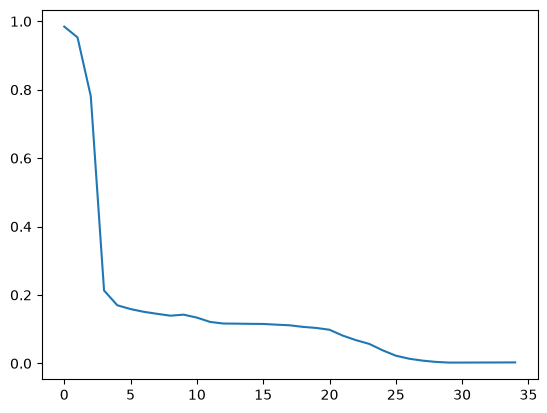

In [155]:
plt.plot(test_out[4])

In [156]:
min(test_out[4])

0.0022468939423561096

In [157]:
test_out[6], test_out[7]

(np.complex64(8.086722e-13+0j), np.complex64(1.4833978e-12+0j))

In [158]:
test_out[8]

array([2.03398267e-02, 6.73312368e-03, 5.35703890e-03, 4.03536036e-03,
       3.16073406e-03, 2.31765145e-03, 2.09099016e-03, 1.16040744e-03,
       9.10051353e-04, 6.97092233e-04, 5.97563054e-04, 3.95998638e-04,
       3.32431025e-04, 1.97381076e-04, 1.10623205e-04, 5.40619701e-05])

In [159]:
test_out[9]

np.complex128(-0.9999999999991946+5.551115123125783e-17j)

In [160]:
test_out[10]

np.complex128(-0.9999999999998331+4.163336342344337e-17j)

In [161]:
test_out[11]

[np.float64(0.043848291445481906),
 np.float64(0.062369715886953336),
 np.float64(0.06973657122753155),
 np.float64(0.07005714012113508),
 np.float64(0.07007793088632497),
 np.float64(0.07007960910660073),
 np.float64(0.07007975221625806),
 np.float64(0.07007976457040035),
 np.float64(0.0700797656400077),
 np.float64(0.07007976573269493),
 np.float64(0.07007976574073002),
 np.float64(0.07007976574142676),
 np.float64(0.07007976574148712),
 np.float64(0.07007976574149245),
 np.float64(0.07007976574149288),
 np.float64(0.07007976574149291),
 np.float64(0.07007976574149292),
 np.float64(0.07007976574149294),
 np.float64(0.07007976574149292),
 np.float64(0.07007976574149294),
 np.float64(0.07007976574149295),
 np.float64(0.07007976574149295),
 np.float64(0.07007976574149291),
 np.float64(0.07007976574149292),
 np.float64(0.07007976574149292),
 np.float64(0.07007976574149294),
 np.float64(0.07007976574149294),
 np.float64(0.07007976574149292),
 np.float64(0.07007976574149288),
 np.float64(0

Very small overlaps!

In [162]:
test_out[12]

[[np.float32(0.61199105),
  np.float32(0.8530396),
  array([1.87668320e-01, 5.06120685e-02, 3.09431990e-02, 1.53148670e-02,
         1.26283021e-02, 8.50391668e-03, 7.15114283e-03, 4.69956106e-03,
         3.26446533e-03, 1.88777947e-03, 1.80342085e-03, 7.40342754e-04,
         5.02498957e-04, 1.83809204e-04, 1.68302355e-04, 1.03010270e-04]),
  np.complex128(-1.0000000065192582+2.220446049250313e-16j),
  np.complex128(-0.999999880790711+1.5832483768463135e-08j),
  np.float64(0.5325484192800014)],
 [np.float32(0.54377186),
  np.float32(0.8530396),
  array([1.60452120e-01, 4.00104668e-02, 1.86424748e-02, 1.27552402e-02,
         1.10317437e-02, 8.84307611e-03, 5.21126182e-03, 4.26347849e-03,
         2.71525436e-03, 9.40724576e-04, 7.74987580e-04, 5.51344408e-04,
         2.10932992e-04, 8.65618030e-05, 7.47524709e-05, 2.30025170e-05]),
  np.complex128(-1.0000000372529032+1.942890293094024e-16j),
  np.complex128(-1.0000000298023222+8.440112497787311e-10j),
  np.float64(0.4534224760539385

## Round 4 - Depth 1, offset 1 - larger defect operators

In [163]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(4, 16)),
    'left_symmetry_sites': list(range(4, 10)),
    'right_symmetry_sites': list(range(10, 16)),
    'left_defect_sites': list(range(4, 8)),
    'right_defect_sites': list(range(12, 16))
}

In [164]:
domains_dict

{'num_system_sites': 20,
 'symmetry_sites': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 'left_symmetry_sites': [4, 5, 6, 7, 8, 9],
 'right_symmetry_sites': [10, 11, 12, 13, 14, 15],
 'left_defect_sites': [4, 5, 6, 7],
 'right_defect_sites': [12, 13, 14, 15]}

In [165]:
depth=1
offset=1

In [166]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [167]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict, depth, offset)

In [168]:
test_out = extract_time_reversal_information(
    rand_psi,
    domains_dict
)

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(


In [169]:
test_out[0]

array([0.25])

In [170]:
test_out[1]

(array([0.24888873, 0.01779391, 0.01315115, 0.00805121]),
 np.complex128(-1.000000000000004-1.249000902703301e-16j),
 np.complex128(-1.0000000000000038-5.551115123125783e-17j),
 [np.float64(0.7528918221991006),
  np.float64(0.9947658972443795),
  np.float64(0.995554931883563),
  np.float64(0.9955549366399581),
  np.float64(0.9955549366400059),
  np.float64(0.9955549366400063),
  np.float64(0.9955549366400064),
  np.float64(0.9955549366400065),
  np.float64(0.9955549366400059),
  np.float64(0.995554936640006),
  np.float64(0.9955549366400059),
  np.float64(0.9955549366400063),
  np.float64(0.9955549366400058),
  np.float64(0.9955549366400062),
  np.float64(0.995554936640006),
  np.float64(0.9955549366400063),
  np.float64(0.9955549366400059),
  np.float64(0.9955549366400062),
  np.float64(0.9955549366400063),
  np.float64(0.9955549366400063),
  np.float64(0.9955549366400063),
  np.float64(0.9955549366400063),
  np.float64(0.995554936640006),
  np.float64(0.9955549366400062),
  np.float6

In [171]:
test_out[2]

np.complex128(4.48650924261597e-31+0j)

In [172]:
test_out[3]

[[np.float64(0.25000000000000133),
  array([0.4965809 , 0.04120511, 0.04120511, 0.0034191 ]),
  np.complex128(-0.9999999999999996+5.551115123125783e-17j),
  np.complex128(-1.0000000000000004+5.551115123125783e-17j),
  [np.float64(0.9930726218361343),
   np.float64(0.996882656983242),
   np.float64(0.9999149137049562),
   np.float64(0.9999976882672668),
   np.float64(0.9999999371997725),
   np.float64(0.9999999982939838),
   np.float64(0.9999999999536555),
   np.float64(0.9999999999987416),
   np.float64(0.9999999999999665),
   np.float64(0.9999999999999996),
   np.float64(1.0000000000000007),
   np.float64(1.000000000000001),
   np.float64(1.000000000000001),
   np.float64(1.0000000000000004),
   np.float64(0.9999999999999999),
   np.float64(1.0000000000000004),
   np.float64(1.0000000000000004),
   np.float64(1.0000000000000007),
   np.float64(0.9999999999999999),
   np.float64(1.0000000000000007),
   np.float64(1.0000000000000009),
   np.float64(1.000000000000001),
   np.float64(1.00

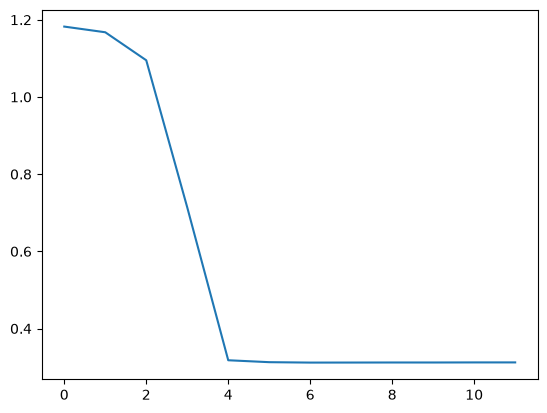

In [173]:
plt.plot(test_out[4])

In [174]:
min(test_out[4])

0.3118354380130768

In [175]:
test_out[6], test_out[7]

(np.complex64(5.6137625e-13+0j), np.complex64(5.807957e-13+0j))

In [176]:
test_out[8]

array([1.00064215e-01, 1.20985250e-03, 1.09746978e-03, 1.07109149e-03,
       9.48884855e-04, 9.32030715e-04, 8.93273154e-04, 8.87309570e-04,
       8.32189074e-04, 7.92919546e-04, 7.60187077e-04, 7.26977449e-04,
       7.25064378e-04, 6.92841851e-04, 6.49878611e-04, 6.36814456e-04,
       6.27395238e-04, 5.97184069e-04, 5.69819616e-04, 5.41835162e-04,
       5.18825536e-04, 5.08732004e-04, 4.71815743e-04, 4.51166309e-04,
       4.34173785e-04, 4.31924028e-04, 3.97102183e-04, 3.93004807e-04,
       3.45638360e-04, 3.43724844e-04, 2.98916233e-04, 2.21240779e-05,
       2.04396346e-05, 1.94084786e-05, 1.87746587e-05, 1.86772126e-05,
       1.83371350e-05, 1.73862223e-05, 1.73151589e-05, 1.67306519e-05,
       1.63784495e-05, 1.61589643e-05, 1.58147175e-05, 1.55729547e-05,
       1.49262818e-05, 1.47955140e-05, 1.45456980e-05, 1.44052718e-05,
       1.41444604e-05, 1.39969807e-05, 1.38067798e-05, 1.37579246e-05,
       1.34506520e-05, 1.32904581e-05, 1.28820744e-05, 1.28091681e-05,
      

In [177]:
test_out[9]

np.complex128(0.9999999999712506+8.902598980925491e-08j)

In [178]:
test_out[10]

np.complex128(0.9999999999028855+5.56053384996591e-07j)

In [179]:
test_out[11]

[np.float64(0.3908492937771252),
 np.float64(0.6701657287061223),
 np.float64(0.6705820262966112),
 np.float64(0.67058209742485),
 np.float64(0.6705820976369468),
 np.float64(0.6705820976394596),
 np.float64(0.6705820976394907),
 np.float64(0.6705820976394905),
 np.float64(0.6705820976394912),
 np.float64(0.670582097639491),
 np.float64(0.6705820976394907),
 np.float64(0.670582097639491),
 np.float64(0.6705820976394905),
 np.float64(0.6705820976394907),
 np.float64(0.6705820976394908),
 np.float64(0.6705820976394907),
 np.float64(0.6705820976394907),
 np.float64(0.6705820976394907),
 np.float64(0.6705820976394907),
 np.float64(0.6705820976394907),
 np.float64(0.6705820976394906),
 np.float64(0.6705820976394904),
 np.float64(0.6705820976394905),
 np.float64(0.6705820976394904),
 np.float64(0.6705820976394907),
 np.float64(0.6705820976394907),
 np.float64(0.6705820976394907),
 np.float64(0.6705820976394904),
 np.float64(0.6705820976394907),
 np.float64(0.6705820976394907),
 np.float64(0.

In [180]:
test_out[12]

[[np.float32(0.28733778),
  np.float32(0.3104258),
  array([2.65846642e-01, 5.21247254e-03, 4.84769900e-03, 4.42429444e-03,
         4.32232984e-03, 4.28400662e-03, 3.87203564e-03, 3.81106108e-03,
         3.62329157e-03, 3.42366602e-03, 3.19985541e-03, 3.04387015e-03,
         2.99362165e-03, 2.91338419e-03, 2.61044655e-03, 2.41466184e-03,
         2.27456979e-03, 2.24600187e-03, 2.15804442e-03, 2.01710342e-03,
         1.90361035e-03, 1.83672665e-03, 1.77358258e-03, 1.74770195e-03,
         1.56644683e-03, 1.46130920e-03, 1.31983685e-03, 1.26751594e-03,
         1.23694542e-03, 1.02463386e-03, 1.02057982e-03, 1.04593697e-04,
         9.32053270e-05, 8.98858929e-05, 8.86639545e-05, 8.68952538e-05,
         8.14813342e-05, 7.78506817e-05, 7.72598700e-05, 7.54596053e-05,
         7.30472833e-05, 6.95118969e-05, 6.83731150e-05, 6.74390231e-05,
         6.70748011e-05, 6.51635660e-05, 6.49076312e-05, 6.37661058e-05,
         6.32906305e-05, 6.17358928e-05, 6.12176102e-05, 6.03979226e-05,


## Round 5 - Depth 1, offset 1, 16 sites, 4 defect sites

In [271]:
domains_dict = {
    'num_system_sites': 16,
    'symmetry_sites': list(range(2, 14)),
    'left_symmetry_sites': list(range(2, 8)),
    'right_symmetry_sites': list(range(8, 14)),
    'left_defect_sites': [2,3,4,5],
    'right_defect_sites': [10,11, 12, 13]
}

In [272]:
depth=1
offset=1

In [273]:
vertical_bond_dimension=16
horizontal_bond_dimension=16

In [274]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [275]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict, depth, offset)

In [276]:
test_out = extract_time_reversal_information(
    rand_psi,
    domains_dict
)

In [277]:
test_out[0]

array([0.1767767])

In [278]:
test_out[1]

(array([0.15853917, 0.07812935, 0.00291011, 0.00163288]),
 np.complex128(-1.0000000000000036-1.1102230246251565e-16j),
 np.complex128(-1.000000000000003-5.551115123125783e-17j),
 [np.float64(0.5904106976171957),
  np.float64(0.8691171612028425),
  np.float64(0.8968330015038719),
  np.float64(0.8968330040643134),
  np.float64(0.8968330040644835),
  np.float64(0.8968330040644839),
  np.float64(0.8968330040644832),
  np.float64(0.8968330040644833),
  np.float64(0.8968330040644834),
  np.float64(0.8968330040644832),
  np.float64(0.8968330040644835),
  np.float64(0.8968330040644834),
  np.float64(0.8968330040644835),
  np.float64(0.8968330040644832),
  np.float64(0.8968330040644832),
  np.float64(0.8968330040644832),
  np.float64(0.8968330040644833),
  np.float64(0.8968330040644832),
  np.float64(0.8968330040644832),
  np.float64(0.8968330040644832),
  np.float64(0.8968330040644831),
  np.float64(0.8968330040644832),
  np.float64(0.8968330040644833),
  np.float64(0.8968330040644834),
  np.f

In [279]:
test_out[2]

np.complex128(1.2213461229641459e-30+0j)

In [280]:
test_out[3]

[[np.float64(0.25000000000000117),
  array([0.25625377, 0.15790312, 0.15790312, 0.09729962]),
  np.complex128(-0.9999992195453182+2.32586962989334e-06j),
  np.complex128(-0.9999990218299191-2.915090571209422e-06j),
  [np.float64(0.5682423320669723),
   np.float64(0.989347757194788),
   np.float64(0.9913255301351901),
   np.float64(0.9929630451841598),
   np.float64(0.9943094180465756),
   np.float64(0.9954100776240296),
   np.float64(0.9963056521505497),
   np.float64(0.9970315749533882),
   np.float64(0.9976181626442251),
   np.float64(0.9980909732512103),
   np.float64(0.9984713062694933),
   np.float64(0.9987767525469211),
   np.float64(0.9990217369984186),
   np.float64(0.9992180220678901),
   np.float64(0.9993751565340196),
   np.float64(0.9995008647802679),
   np.float64(0.9996013778550301),
   np.float64(0.9996817109719),
   np.float64(0.9997458935896522),
   np.float64(0.9997971585923846),
   np.float64(0.999838096843967),
   np.float64(0.9998707828253348),
   np.float64(0.9998

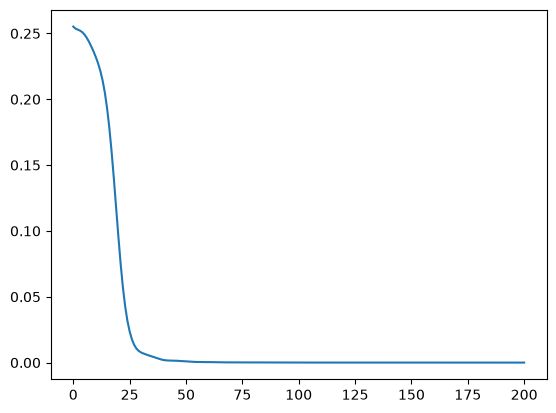

In [281]:
plt.plot(test_out[4])

In [282]:
min(test_out[4])

1.0967254638671875e-05

In [283]:
test_out[6], test_out[7]

(np.complex64(5.684551e-12+0j), np.complex64(5.7097235e-12+0j))

In [284]:
test_out[8]

array([1.74614831e-01, 4.28290560e-04, 3.52141159e-04, 1.64097528e-04,
       1.40172276e-04, 1.28073150e-04, 1.10823584e-04, 9.80725351e-05,
       9.52722010e-05, 8.64313337e-05, 8.22145646e-05, 7.99403140e-05,
       7.35810964e-05, 7.07198731e-05, 6.29937110e-05, 6.00258623e-05,
       5.57083848e-05, 5.41355252e-05, 5.35826960e-05, 4.98010532e-05,
       4.27065175e-05, 4.20184179e-05, 3.92144384e-05, 3.57300534e-05,
       3.50035121e-05, 3.18207979e-05, 3.10974378e-05, 3.09059464e-05,
       2.92784018e-05, 2.65149771e-05, 2.46698086e-05, 2.36587601e-05,
       2.32346792e-05, 2.17970892e-05, 2.17404715e-05, 1.99762699e-05,
       1.98715642e-05, 1.89410105e-05, 1.70978455e-05, 1.69428586e-05,
       1.62599159e-05, 1.48629459e-05, 1.38458287e-05, 1.37314768e-05,
       1.24274379e-05, 1.23036972e-05, 1.13191438e-05, 1.12845166e-05,
       1.05362089e-05, 1.05262674e-05, 9.68744700e-06, 8.83450153e-06,
       8.42708113e-06, 7.85470899e-06, 7.15068839e-06, 6.74209548e-06,
      

In [285]:
test_out[9]

np.complex128(-0.9999999999552063-1.3128947928819912e-10j)

In [286]:
test_out[10]

np.complex128(-0.9999999999903267+1.8705781368311136e-10j)

In [287]:
test_out[11]

[np.float64(0.42813760144020635),
 np.float64(0.9877843025040957),
 np.float64(0.9878443593375693),
 np.float64(0.9878444043504795),
 np.float64(0.987844404503165),
 np.float64(0.9878444045043395),
 np.float64(0.9878444045043513),
 np.float64(0.9878444045043513),
 np.float64(0.987844404504352),
 np.float64(0.9878444045043517),
 np.float64(0.9878444045043512),
 np.float64(0.9878444045043506),
 np.float64(0.9878444045043508),
 np.float64(0.9878444045043511),
 np.float64(0.9878444045043513),
 np.float64(0.9878444045043513),
 np.float64(0.9878444045043513),
 np.float64(0.9878444045043515),
 np.float64(0.9878444045043515),
 np.float64(0.9878444045043517),
 np.float64(0.9878444045043517),
 np.float64(0.9878444045043512),
 np.float64(0.987844404504352),
 np.float64(0.9878444045043512),
 np.float64(0.9878444045043515),
 np.float64(0.9878444045043516),
 np.float64(0.9878444045043513),
 np.float64(0.9878444045043508),
 np.float64(0.9878444045043511),
 np.float64(0.9878444045043511),
 np.float64(

In [288]:
test_out[12]

[[np.float32(1.0220388),
  np.float32(1.0032398),
  array([3.53551087e-01, 4.30621184e-04, 3.12146187e-04, 2.64241268e-04,
         2.35938251e-04, 2.17430042e-04, 1.86995740e-04, 1.83337122e-04,
         1.62354088e-04, 1.47223549e-04, 1.41892227e-04, 1.32516936e-04,
         1.22061360e-04, 1.15349448e-04, 9.76345528e-05, 9.32878375e-05,
         8.77721276e-05, 7.85003971e-05, 7.20292888e-05, 7.05124140e-05,
         5.75048783e-05, 5.69326930e-05, 5.34793689e-05, 4.62538086e-05,
         4.49417182e-05, 4.39877084e-05, 3.60677048e-05, 3.59529671e-05,
         3.15319454e-05, 3.05181177e-05, 2.45848966e-05, 2.15676175e-05,
         2.00115392e-05, 1.78966224e-05, 1.76347233e-05, 1.43284677e-05,
         1.32871268e-05, 1.10620242e-05, 1.00981153e-05, 9.58611067e-06,
         7.80710847e-06, 7.00849052e-06, 6.78267260e-06, 6.07552782e-06,
         5.91135337e-06, 5.07021278e-06, 4.08846952e-06, 3.40957569e-06,
         2.97590751e-06, 2.55864788e-06, 2.53752830e-06, 1.58658697e-06,
 

## Round 6 - Depth 1, offset 1 - larger defect operators - improved factorization algorithm

In [289]:
domains_dict = {
    'num_system_sites': 20,
    'symmetry_sites': list(range(4, 16)),
    'left_symmetry_sites': list(range(4, 10)),
    'right_symmetry_sites': list(range(10, 16)),
    'left_defect_sites': list(range(4, 8)),
    'right_defect_sites': list(range(12, 16))
}

In [290]:
domains_dict

{'num_system_sites': 20,
 'symmetry_sites': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 'left_symmetry_sites': [4, 5, 6, 7, 8, 9],
 'right_symmetry_sites': [10, 11, 12, 13, 14, 15],
 'left_defect_sites': [4, 5, 6, 7],
 'right_defect_sites': [12, 13, 14, 15]}

In [291]:
depth=1
offset=1

In [292]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [293]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict, depth, offset)

In [295]:
(
    vertical_bond_dimension,
    horizontal_bond_dimension
)

(16, 16)

In [301]:
start_time = time()
test_out = extract_factorization_time_reversal_information(
    rand_psi,
    domains_dict
)
end_time = time()

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from complex64 to complex128.
  warnings.warn(


In [302]:
end_time - start_time

56.44615149497986

In [303]:
test_out[0]

array([0.0625])

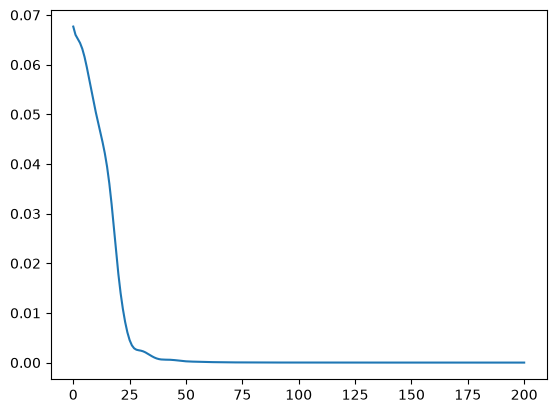

In [305]:
plt.plot(test_out[1])

In [307]:
test_out[3], test_out[4]

(np.complex64(1.3898372e-12+0j), np.complex64(9.228837e-13+0j))

In [309]:
test_out[5][:10]

array([6.17686092e-02, 3.73747197e-04, 1.77161110e-04, 1.10675975e-04,
       9.49361004e-05, 8.68461256e-05, 8.34445596e-05, 7.85870961e-05,
       7.67977782e-05, 7.15778089e-05])

In [310]:
test_out[6], test_out[7]

(np.complex128(-0.9999999999999665-5.551115123125783e-17j),
 np.complex128(-0.9999999999999867-8.326672684688674e-17j))

In [311]:
test_out[8]

[np.float64(0.5424237479478144),
 np.float64(0.9882866411174758),
 np.float64(0.9882923475946819),
 np.float64(0.9882923476043934),
 np.float64(0.9882923476043938),
 np.float64(0.9882923476043936),
 np.float64(0.9882923476043928),
 np.float64(0.988292347604393),
 np.float64(0.9882923476043936),
 np.float64(0.9882923476043937),
 np.float64(0.9882923476043932),
 np.float64(0.9882923476043937),
 np.float64(0.9882923476043937),
 np.float64(0.9882923476043932),
 np.float64(0.9882923476043937),
 np.float64(0.9882923476043934),
 np.float64(0.9882923476043929),
 np.float64(0.9882923476043931),
 np.float64(0.9882923476043938),
 np.float64(0.9882923476043941),
 np.float64(0.9882923476043938),
 np.float64(0.9882923476043934),
 np.float64(0.9882923476043931),
 np.float64(0.9882923476043934),
 np.float64(0.9882923476043934),
 np.float64(0.9882923476043936),
 np.float64(0.9882923476043934),
 np.float64(0.9882923476043936),
 np.float64(0.9882923476043934),
 np.float64(0.9882923476043938),
 np.float64

In [312]:
test_out[9]

[[np.float32(0.36603132),
  np.float32(0.35444608),
  array([2.49996087e-01, 5.70786906e-04, 4.49062592e-04, 4.37025329e-04,
         3.72073675e-04, 3.26064996e-04, 3.20765682e-04, 2.77820925e-04,
         2.61974498e-04, 2.43808161e-04, 2.33628737e-04, 2.13584408e-04,
         2.03887827e-04, 1.95471413e-04, 1.94738247e-04, 1.81186227e-04,
         1.64032549e-04, 1.62819349e-04, 1.55714547e-04, 1.52314930e-04,
         1.47252846e-04, 1.35697910e-04, 1.31371202e-04, 1.24675130e-04,
         1.18897983e-04, 1.14562890e-04, 1.07624701e-04, 1.06345734e-04,
         1.01556687e-04, 1.00655048e-04, 9.57711961e-05, 9.24944041e-05,
         8.85492490e-05, 8.14041270e-05, 7.51061711e-05, 7.21677274e-05,
         7.01457565e-05, 6.89085557e-05, 6.35240048e-05, 6.28057392e-05,
         5.72676591e-05, 5.31182467e-05, 5.31149937e-05, 4.82576930e-05,
         4.63995586e-05, 4.57587349e-05, 3.96862628e-05, 3.88144796e-05,
         3.80085741e-05, 3.57260913e-05, 3.13692890e-05, 2.73086719e-05,

# Summary of results
| # Sites | # Sym sites | # Def sites | Depth | Offset | rho ent | rho' ent |  rho' works | rho' cut works | rho' factor works | rho' factor cut works |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 16 | 8 | 2 | 0 | 0 | No | No | Yes | Yes | Yes | Yes |
| 16 | 8 | 2 | 1 | 0 | No | Yes | Yes | Yes | Yes | Yes |
| 16 | 8 | 2 | 1 | 1 | No | Yes | No | No | Yes | Yes |
| 20 | 12 | 4 | 1 | 1 | No | No | Yes | Somewhat | Yes | Yes |
| 16 | 12 | 4 | 1 | 1 | No | No | Yes | Yes | Yes | Yes |

# Conclusions
It looks like we need a larger system in order to explore these longer correlations.

# Tests
## Cluster state

In [47]:
psi = get_cluster_state_qu_tensor_network(12)

In [48]:
(psi & psi.conj()).contract()

np.float64(0.9999999999999974)

In [62]:
psi = get_cluster_state_qu_tensor_network(32)

In [63]:
(psi & psi.conj()).contract()

np.float64(0.999999999999993)

Compute 3 site rdm, have an analytic expression.

In [64]:
rdm = (
    psi
    & (
        psi
        .mangle_inner_()
        .conj()
        .reindex({f'k{i}': f'b{i}' for i in range(3)})
    )
)

In [65]:
psi

TensorNetwork(tensors=64, indices=96)

In [72]:
rdm = rdm.contract(
    output_inds=['k0', 'k1', 'k2', 'b0', 'b1', 'b2'],
    inplace=True
)

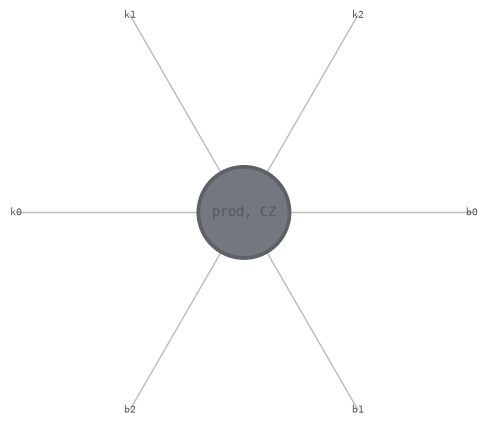

In [73]:
rdm.draw()

In [76]:
np_X = np.array([[0,1], [1,0]])
np_Z = np.array([[1,0], [0,-1]])

In [86]:
test_rdm = (1/8)*(multikron([np_Z, np_X, np_Z]) + np.eye(8)).reshape((2,)*6)

In [91]:
rdm

TensorNetwork(tensors=1, indices=6)

In [98]:
np.linalg.norm(test_rdm - rdm.tensors[0].data)

np.float64(3.497202527569243e-15)

Looks good.

# Old code

## Apply random symmetries test

In [13]:
psi = groundstates[0]

In [15]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [16]:
print(basis)

reference states: 
array index   /   Fock state   /   integer repr. 
     0.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1>  65535 
     1.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0>  65534 
     2.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1>  65533 
     3.  |1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0>  65532 
     4.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1>  65531 
     5.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0>  65530 
     6.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1>  65529 
     7.  |1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0>  65528 
     8.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1>  65527 
     9.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0>  65526 
    10.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1>  65525 
    11.  |1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0>  65524 
    12.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1>  65523 
    13.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0>  65522 
    14.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1>  65521 
    15.  |1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0>  65520 
    16.  |1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1>  65519 
    17.  |1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0>  65518 
    18.  |1 1

In [14]:
psi

array([[ 3.90582915e-03+5.73388357e-05j],
       [-5.73388357e-05+3.90582915e-03j],
       [-5.73388357e-05+3.90582915e-03j],
       ...,
       [ 5.73388357e-05-3.90582915e-03j],
       [ 5.73388357e-05-3.90582915e-03j],
       [ 3.90582915e-03+5.73388357e-05j]], shape=(65536, 1))

In [18]:
np.arange(16).reshape((2,)*4)

array([[[[ 0,  1],
         [ 2,  3]],

        [[ 4,  5],
         [ 6,  7]]],


       [[[ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15]]]])

In [22]:
qu_psi = qtn.Tensor(
    psi[::-1].reshape((2,)*num_sites),
    inds=[f'k{i}' for i in range(num_sites)]
)

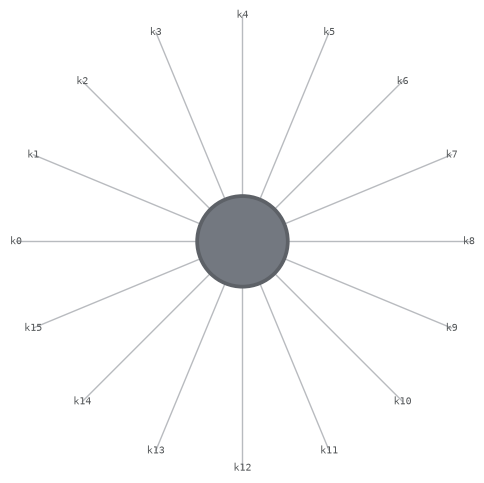

In [23]:
qu_psi.draw()

In [24]:
qu_psi

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k0', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15'), tags=oset([]))

In [50]:
u = qu.gen.rand.rand_uni(4)

In [51]:
np.round(u, 3)

[[ 0.21 -0.234j  0.652+0.471j -0.069+0.35j   0.352-0.063j]
 [ 0.135-0.189j  0.028+0.158j  0.161-0.832j  0.336-0.297j]
 [-0.104-0.254j -0.546-0.004j -0.043+0.381j  0.424-0.548j]
 [-0.657-0.583j -0.056+0.163j  0.049-0.071j  0.048+0.434j]]

In [52]:
np.round(u @ u.T.conj(), 3)

[[ 1.+0.j -0.-0.j -0.-0.j -0.+0.j]
 [-0.+0.j  1.+0.j  0.-0.j  0.-0.j]
 [-0.+0.j  0.+0.j  1.+0.j  0.-0.j]
 [-0.-0.j  0.+0.j  0.+0.j  1.+0.j]]

In [28]:
type(u)

quimb.core.qarray

In [29]:
qu_u = qtn.Tensor(
    qu.gen.rand.rand_uni(4).reshape((2,)*4),
    inds=['k1', 'k2', 'b1', 'b2']
)

In [30]:
out_qu_psi = (
    qu_psi.reindex({'k1': 'b1', 'k2': 'b2'})
    & qu_u
)

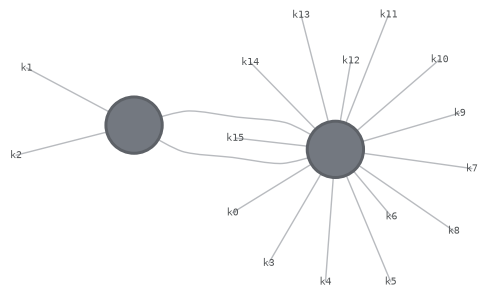

In [32]:
out_qu_psi.draw()

In [33]:
out_qu_psi.contract(inplace=True)

TensorNetwork(tensors=1, indices=16)

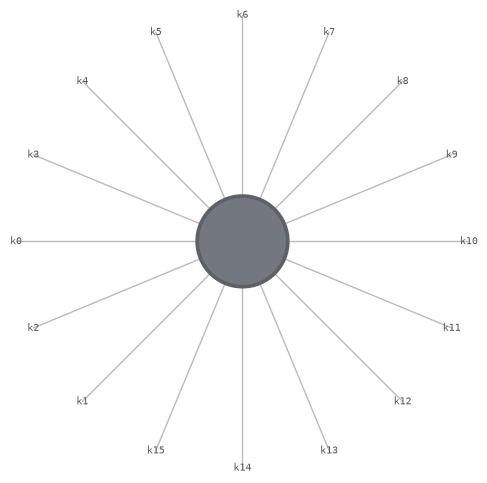

In [34]:
out_qu_psi.draw()

In [37]:
X = out_qu_psi.tensors[0].data.reshape((-1))[::-1]

In [38]:
X.shape

(65536,)

In [39]:
X

array([-0.00220717+0.00142551j, -0.00310542-0.00063017j,
        0.00343488-0.0033824j , ...,  0.00310542+0.00063017j,
       -0.00343488+0.0033824j , -0.00174788+0.00421859j], shape=(65536,))

In [54]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quspin_state(psi):
    qu_psi = qtn.Tensor(
        psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    for delta in [0,1]:
        for i in range(num_sites//2):
            site_1 = ((2*i)+delta)%num_sites
            site_2 = ((2*i)+1+delta)%num_sites
    
            qu_u = qtn.Tensor(
                qu.gen.rand.rand_uni(4).reshape((2,)*4),
                inds=[f'k{site_1}', f'k{site_2}', f'b{site_1}', f'b{site_2}']
            )
    
            qu_psi = (
                qu_psi.reindex(
                    {f'k{site_1}':  f'b{site_1}', f'k{site_2}': f'b{site_2}'}
                )
                & qu_u
            )
            qu_psi.contract(inplace=True)

    out_psi = qu_psi.tensors[0].data.reshape((-1))[::-1]

    return out_psi

In [64]:
test_psis = [
    apply_haar_random_fdlu_to_quspin_state(psi) 
    for _ in range(100)
]

In [67]:
diffs = list()

for psi_rand in test_psis:
    overlap = np.dot(psi.conj()[:, 0], psi_rand)
    diffs.append(overlap)

diffs = np.array(diffs)

In [69]:
np.round(diffs, 3)

array([ 0.001-0.003j, -0.   -0.002j, -0.   -0.001j, -0.004+0.005j,
        0.001-0.003j, -0.   +0.j   ,  0.01 +0.002j, -0.   -0.j   ,
        0.003-0.001j,  0.001+0.001j,  0.001+0.j   ,  0.   +0.j   ,
       -0.001-0.j   ,  0.002-0.001j, -0.   -0.001j, -0.001-0.001j,
       -0.   -0.j   ,  0.   -0.j   ,  0.001-0.j   , -0.   -0.j   ,
        0.001-0.j   ,  0.004+0.004j, -0.001-0.003j, -0.001-0.004j,
        0.003-0.001j, -0.007+0.013j, -0.   -0.001j, -0.   -0.001j,
        0.   -0.j   , -0.001-0.001j,  0.001-0.002j, -0.001-0.j   ,
       -0.   -0.j   ,  0.   +0.002j,  0.   +0.001j, -0.   -0.002j,
        0.002-0.001j,  0.001+0.001j,  0.002+0.005j,  0.   -0.001j,
       -0.003-0.j   , -0.001+0.004j, -0.002-0.002j, -0.   -0.j   ,
       -0.   +0.j   ,  0.003+0.006j, -0.   +0.j   , -0.002-0.001j,
       -0.001+0.002j, -0.   +0.004j, -0.004+0.004j,  0.002+0.j   ,
        0.002-0.002j, -0.   +0.j   , -0.002+0.002j,  0.   -0.j   ,
       -0.   +0.001j, -0.002+0.001j, -0.001-0.001j,  0.001-0.0

In [70]:
from itertools import combinations

In [71]:
diffs = list()

for psi_1, psi_2 in combinations(test_psis, 2):
    overlap = np.dot(psi_1.conj(), psi_2)
    diffs.append(overlap)

diffs = np.array(diffs)

In [72]:
np.abs(diffs)

array([0.00134098, 0.00037768, 0.00015354, ..., 0.00254437, 0.00191283,
       0.00027508], shape=(4950,))

## Generate and test random unitaries respecting $XK$ symmetry

In [87]:
o = ortho_group.rvs(4)

In [88]:
o

array([[ 0.38102352, -0.79409578,  0.27917744, -0.38248259],
       [ 0.77824464,  0.51678111, -0.07115791, -0.34958419],
       [-0.44998244,  0.28812547,  0.50418709, -0.67845036],
       [ 0.21603739,  0.13904278,  0.81412031,  0.52077161]])

In [89]:
np_H = np.pow(2, -1/2)*np.array([
    [1,1],
    [1,-1]
])

In [90]:
np_W = np.kron(np_H, np_H) @ np.diag([1, 1j, 1j, 1])

In [91]:
np_W

array([[ 0.5+0.j ,  0. +0.5j,  0. +0.5j,  0.5+0.j ],
       [ 0.5+0.j ,  0. -0.5j,  0. +0.5j, -0.5+0.j ],
       [ 0.5+0.j ,  0. +0.5j,  0. -0.5j, -0.5+0.j ],
       [ 0.5+0.j ,  0. -0.5j,  0. -0.5j,  0.5+0.j ]])

In [92]:
u = np_W @ o @ (np_W.conj().T)

In [93]:
u

array([[ 0.49332143-0.28450428j,  0.02172362-0.0980135j ,
         0.20766232+0.77616188j, -0.12564645-0.0653819j ],
       [-0.09789468-0.02225296j,  0.46806024-0.32438915j,
         0.06605992-0.12529131j, -0.27123936-0.75629367j],
       [-0.27123936+0.75629367j,  0.06605992+0.12529131j,
         0.46806024+0.32438915j, -0.09789468+0.02225296j],
       [-0.12564645+0.0653819j ,  0.20766232-0.77616188j,
         0.02172362+0.0980135j ,  0.49332143+0.28450428j]])

In [94]:
qu_u = qtn.Tensor(
    u.reshape((2,)*4),
    inds=['k1', 'k2', 'b1', 'b2']
)

In [95]:
qu_XX_2_site = qtn.Tensor(
    np_XX.reshape((2,)*4),
    inds=['k1', 'k2', 'b1', 'b2']
)   

In [96]:
t1 = (
    qu_XX_2_site.reindex({'b1': 'i1', 'b2': 'i2'})
    & qu_u.reindex({'k1': 'i1', 'k2': 'i2'})
)
t1.contract(inplace=True)

t2 = (
    qu_u.conj().reindex({'b1': 'i1', 'b2': 'i2'})
    & qu_XX_2_site.reindex({'k1': 'i1', 'k2': 'i2'})
)
t2.contract(inplace=True)

TensorNetwork(tensors=1, indices=4)

In [97]:
np.linalg.norm(t1.tensors[0].data - t2.tensors[0].data)

np.float64(0.0)